# AMKGH (Adaptive Momentum Kurtosis Gated Hybrid)
Author: Lakshya Gupta, U20240077

In [1]:
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set plotting style
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["lines.linewidth"] = 2

In [2]:
# ================================================================
# 1. Global Setup: Device & Seeding
# ================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_SEED = 42

def set_seed(seed):
    """Ensure reproducibility across runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(BASE_SEED)

In [3]:
# ================================================================
# 2. The Optimizer: AMKGH
# ================================================================
class AMKGH(torch.optim.Optimizer):
    """
    AMKGH: Adaptive Momentum Kurtosis Gated Hybrid.
    """

    def __init__(
        self,
        params,
        lr=0.002083351357984085,
        betas=(0.898796736862423, 0.9364508430736697),
        beta4=None,           # if None, defaults to beta2
        lambda_k=0.12068838536337394,         # Damping strength
        kurtosis_max=35.516173756001955,    # Safety Cap
        hybrid_weight=0.1,    # The "Bypass" for Rosenbrock
        eps=1e-8,
    ):
        if beta4 is None:
            beta4 = betas[1] 

        defaults = dict(
            lr=lr,
            betas=betas,
            beta4=beta4,
            lambda_k=lambda_k,
            kurtosis_max=kurtosis_max,
            hybrid_weight=hybrid_weight,
            eps=eps,
        )
        super().__init__(params, defaults)


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            beta4 = group["beta4"]
            lambda_k = group["lambda_k"]
            kurtosis_max = group["kurtosis_max"]
            # hybrid_weight is removed, replaced by dynamic gating
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue

                grad = p.grad.data
                
                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["E4"] = torch.zeros_like(p.data)

                m = state["m"]
                v = state["v"]
                E4 = state["E4"]

                state["step"] += 1
                t = state["step"]

                # --- 1. Update Moments ---
                m.mul_(beta1).add_(grad, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                
                # Optimization: Compute g^4 efficiently
                g2 = grad.pow(2)
                g4 = g2.pow(2)
                E4.mul_(beta4).add_(g4, alpha=1 - beta4)

                # --- 2. Bias Correction ---
                bias_corr1 = 1 - beta1**t
                bias_corr2 = 1 - beta2**t
                
                m_hat = m / bias_corr1
                v_hat = v / bias_corr2

                # --- 3. Kurtosis Calculation ---
                # K = E[x^4] / (E[x^2])^2
                K_t = E4 / (v_hat.pow(2) + eps)
                
                # Soft Clip helps MNIST more than Hard Clip (Smoother transitions)
                K_clipped = torch.clamp(K_t, max=kurtosis_max)

                # Damping/Gating Factor s_t
                # s_t approaches 1.0 when K is low (Gaussian/Stable)
                # s_t approaches 0.0 when K is high (Heavy-Tailed/Unstable)
                s_t = 1.0 / (1.0 + lambda_k * K_clipped)

                # --- 4. INNOVATION: Kurtosis-Gated Channel Switching ---
                
                # Direction A: Smart (Adam-like)
                # We do NOT apply s_t here anymore, s_t is used for mixing later
                denom = torch.sqrt(v_hat) + eps
                smart_dir = m_hat / denom

                # Direction B: Dumb (SGD-like)
                dumb_dir = m 

                # Gated Mix: 
                # If Stable (s_t -> 1): Use Smart Dir
                # If Unstable (s_t -> 0): Use Dumb Dir
                # We assume Adam step is ~1, so we scale dumb dir to match magnitude context
                
                # Final Calculation
                hybrid_dir = (s_t * smart_dir) + ((1.0 - s_t) * dumb_dir)

                # --- 5. Apply Update ---
                p.data.add_(hybrid_dir, alpha=-lr)

        return loss

In [4]:
# ================================================================
# 3. Helper Functions
# ================================================================
def make_spd_matrix(dim=20, cond=10):
    """Generates a random symmetric positive-definite matrix."""
    # Create random orthogonal matrix
    Q_mat, _ = np.linalg.qr(np.random.randn(dim, dim))
    # Set eigenvalues linearly spaced from 1 to cond
    eigs = np.linspace(1, cond, dim)
    # Construct matrix: Q * diag(eigs) * Q^T
    return Q_mat @ np.diag(eigs) @ Q_mat.T

In [5]:
# ================================================================
# 4. Experiment: Quadratic Functions
# ================================================================
def run_quadratic(cond, dim=20, trials=3, max_iter=2500, tol=1e-6):
    print(f"\n=== Experiment: Quadratic (Condition Number={cond}) ===")
    
    # Define Optimizers
    OPTS = {
        "AMKGH":      lambda p: AMKGH(p, lr=1e-2, lambda_k=0.2, hybrid_weight=0.1),
        "Adam":      lambda p: torch.optim.Adam(p, lr=1e-2),
        "SGDM":      lambda p: torch.optim.SGD(p, lr=1e-2, momentum=0.9),
        "RMSprop":   lambda p: torch.optim.RMSprop(p, lr=1e-2),
    }

    def f_quad(x, Q):
        return 0.5 * (x @ Q @ x)

    logs = {name: [] for name in OPTS}

    # Run Trials
    for trial in range(trials):
        print(f"  Trial {trial+1}/{trials}")
        Q_np = make_spd_matrix(dim, cond)
        Q = torch.tensor(Q_np, dtype=torch.float32, device=device)

        for name, opt_ctor in OPTS.items():
            x = torch.randn(dim, device=device, requires_grad=True)
            opt = opt_ctor([x])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                loss = f_quad(x, Q)
                losses.append(loss.item())
                
                if loss.item() < tol:
                    break # Converged
                
                loss.backward()
                opt.step()

            logs[name].append(losses)

    # Visualization (Plotting the first trial)
    plt.figure()
    for name in OPTS:
        plt.plot(logs[name][0], label=name, alpha=0.8)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (Log Scale)")
    plt.title(f"Quadratic Convergence (Cond={cond})")
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend()
    plt.show()

    print("\nConvergence Information:")
    for name in OPTS:
        iters = len(logs[name][0])
        converged = logs[name][0][-1] < tol
        if converged:
            print(f"{name}: Converged in {iters} iterations")
        else:
            print(f"{name}: Did not converge within {max_iter} iterations")

    return logs

In [6]:
# ================================================================
# 5. Experiment: Rosenbrock Function
# ================================================================
def run_rosenbrock(max_iter=5000, tol=1e-4, trials=3):
    print("\n=== Experiment: Rosenbrock Function ===")

    def f_rosen(theta):
        x, y = theta[0], theta[1]
        return (1 - x)**2 + 100 * (y - x**2)**2

    OPTS = {
        "AMKGH":      lambda p: AMKGH(p, lr=1e-3, lambda_k=0.2, hybrid_weight=0.1),
        "Adam":      lambda p: torch.optim.Adam(p, lr=1e-3),
        "SGDM":      lambda p: torch.optim.SGD(p, lr=1e-3, momentum=0.9),
        "RMSprop":   lambda p: torch.optim.RMSprop(p, lr=1e-3),
    }

    logs = {name: [] for name in OPTS}

    for trial in range(trials):
        print(f"  Trial {trial+1}/{trials}")
        for name, opt_ctor in OPTS.items():
            # Standard starting point (-1.2, 1.0)
            theta = torch.tensor([-1.2, 1.0], device=device, requires_grad=True)
            opt = opt_ctor([theta])

            losses = []
            for it in range(max_iter):
                opt.zero_grad()
                loss = f_rosen(theta)
                losses.append(loss.item())
                
                if loss.item() < tol:
                    break
                
                loss.backward()
                opt.step()

            logs[name].append(losses)

    # Visualization
    plt.figure()
    for name in OPTS:
        plt.plot(logs[name][0], label=name, alpha=0.8)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (Log Scale)")
    plt.title("Rosenbrock Convergence")
    plt.grid(True, which="both", ls="-", alpha=0.4)
    plt.legend()
    plt.show()

    print("\nConvergence Information:")
    for name in OPTS:
        iters = len(logs[name][0])
        converged = logs[name][0][-1] < tol
        if converged:
            print(f"{name}: Converged in {iters} iterations")
        else:
            print(f"{name}: Did not converge within {max_iter} iterations")

    return logs

In [7]:
# ================================================================
# 6. Experiment: MNIST Neural Network
# ================================================================
class MNISTNet(nn.Module):
    """Simple MLP: 784 -> 128 -> 64 -> 10"""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

def get_loaders(batch=64):
    transform = transforms.ToTensor()
    try:
        train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
        test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)
    except:
        print("MNIST download failed. Check internet or directory permissions.")
        return None, None
        
    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch, shuffle=False)
    return train_loader, test_loader

def train_epoch(model, opt, loader):
    model.train()
    loss_sum = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item() * x.size(0)
        total += x.size(0)
    return loss_sum / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

def run_mnist(epochs=20):
    print("\n=== Experiment: MNIST Neural Network ===")
    
    train_loader, test_loader = get_loaders()
    if train_loader is None: return

    OPTS = {
        "AMKGH":      lambda p: AMKGH(p, lr=5e-4, lambda_k=0.2, hybrid_weight=0.1),
        "Adam":      lambda p: torch.optim.Adam(p, lr=1e-3),
        "SGDM":      lambda p: torch.optim.SGD(p, lr=1e-3, momentum=0.9),
        # Using lower LR for RMSProp as it can be unstable
        "RMSprop":   lambda p: torch.optim.RMSprop(p, lr=5e-4),
    }

    results = {}

    for name, opt_ctor in OPTS.items():
        print(f"  Training with {name}...")
        set_seed(BASE_SEED + 100) # Same init for fair comparison

        model = MNISTNet().to(device)
        opt = opt_ctor(model.parameters())

        train_losses = []
        test_accs = []
        times = []

        start_total = time.time()
        for epoch in range(1, epochs+1):
            t0 = time.time()
            train_loss = train_epoch(model, opt, train_loader)
            acc = evaluate(model, test_loader)
            dt = time.time() - t0
            times.append(dt)

            train_losses.append(train_loss)
            test_accs.append(acc)
            
            if epoch % 5 == 0 or epoch == 1:
                print(f"    Ep {epoch:02d} | Loss: {train_loss:.4f} | Acc: {acc:.4f} | Time: {dt:.1f}s")

        total_time = time.time() - start_total
        print(f"    Total Time: {total_time:.2f}s | Final Acc: {test_accs[-1]:.4f}")
        
        results[name] = {
            "loss": train_losses,
            "acc": test_accs,
            "time": total_time
        }

    # Plotting MNIST Results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Plot
    for name in results:
        ax1.plot(results[name]["loss"], label=name)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training Loss")
    ax1.set_title("MNIST Training Loss")
    ax1.grid(True)
    ax1.legend()

    # Accuracy Plot
    for name in results:
        ax2.plot(results[name]["acc"], label=name)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Test Accuracy")
    ax2.set_title("MNIST Test Accuracy")
    ax2.grid(True)
    ax2.legend()
    
    plt.show()
    return results

Starting FM216 Project Experiments on cpu

=== Experiment: Quadratic (Condition Number=10) ===
  Trial 1/3
  Trial 2/3
  Trial 3/3
  Trial 2/3
  Trial 3/3


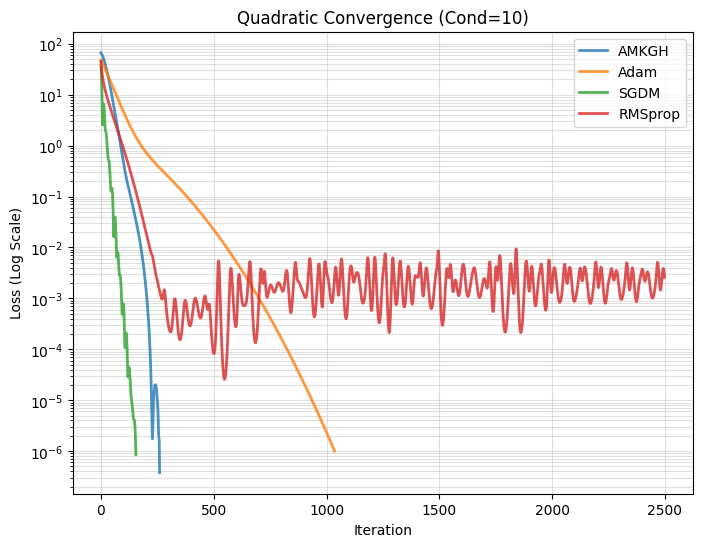


Convergence Information:
AMKGH: Converged in 261 iterations
Adam: Converged in 1037 iterations
SGDM: Converged in 156 iterations
RMSprop: Did not converge within 2500 iterations

=== Experiment: Quadratic (Condition Number=100) ===
  Trial 1/3
  Trial 2/3
  Trial 2/3
  Trial 3/3
  Trial 3/3


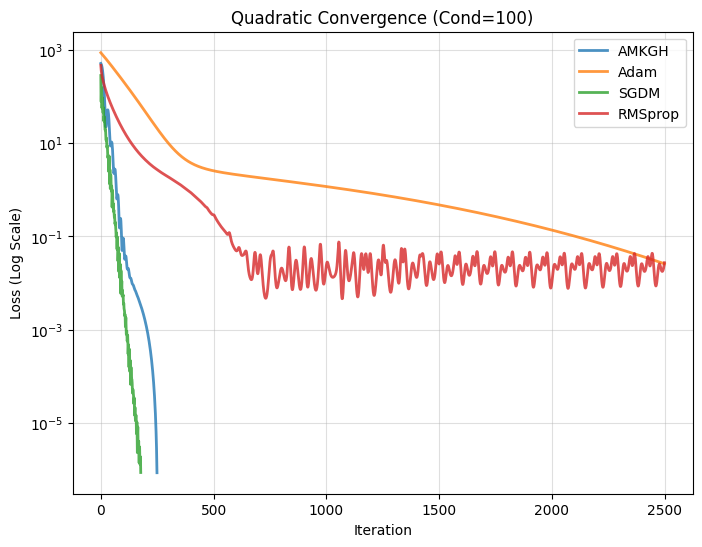


Convergence Information:
AMKGH: Converged in 250 iterations
Adam: Did not converge within 2500 iterations
SGDM: Converged in 178 iterations
RMSprop: Did not converge within 2500 iterations

=== Experiment: Rosenbrock Function ===
  Trial 1/3
  Trial 2/3
  Trial 2/3
  Trial 3/3
  Trial 3/3


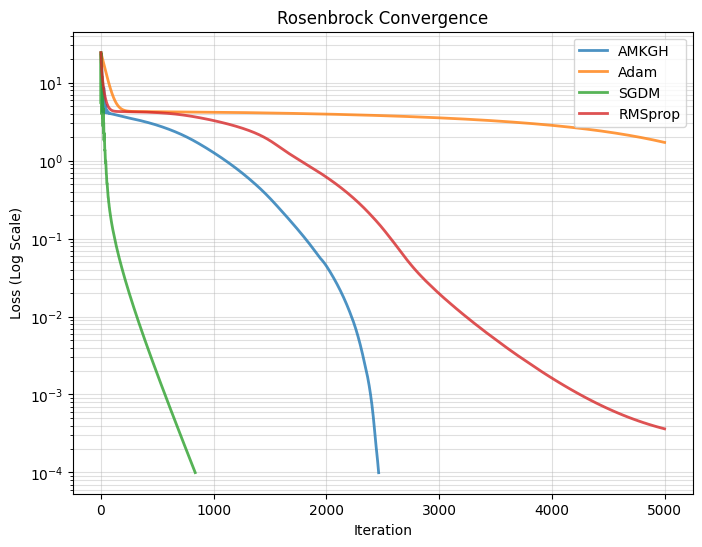


Convergence Information:
AMKGH: Converged in 2464 iterations
Adam: Did not converge within 5000 iterations
SGDM: Converged in 837 iterations
RMSprop: Did not converge within 5000 iterations

=== Experiment: MNIST Neural Network ===
  Training with AMKGH...
    Ep 01 | Loss: 0.4723 | Acc: 0.9306 | Time: 3.9s
    Ep 01 | Loss: 0.4723 | Acc: 0.9306 | Time: 3.9s
    Ep 05 | Loss: 0.0949 | Acc: 0.9678 | Time: 4.0s
    Ep 10 | Loss: 0.0451 | Acc: 0.9773 | Time: 3.9s
    Ep 15 | Loss: 0.0226 | Acc: 0.9776 | Time: 4.1s
    Ep 20 | Loss: 0.0111 | Acc: 0.9781 | Time: 4.2s
    Total Time: 80.08s | Final Acc: 0.9781
  Training with Adam...
    Ep 01 | Loss: 0.3349 | Acc: 0.9476 | Time: 2.8s
    Ep 05 | Loss: 0.0581 | Acc: 0.9757 | Time: 2.7s
    Ep 10 | Loss: 0.0209 | Acc: 0.9770 | Time: 2.9s
    Ep 15 | Loss: 0.0100 | Acc: 0.9746 | Time: 2.8s
    Ep 20 | Loss: 0.0076 | Acc: 0.9691 | Time: 4.0s
    Total Time: 59.08s | Final Acc: 0.9691
  Training with SGDM...
    Ep 01 | Loss: 1.7628 | Acc: 0.80

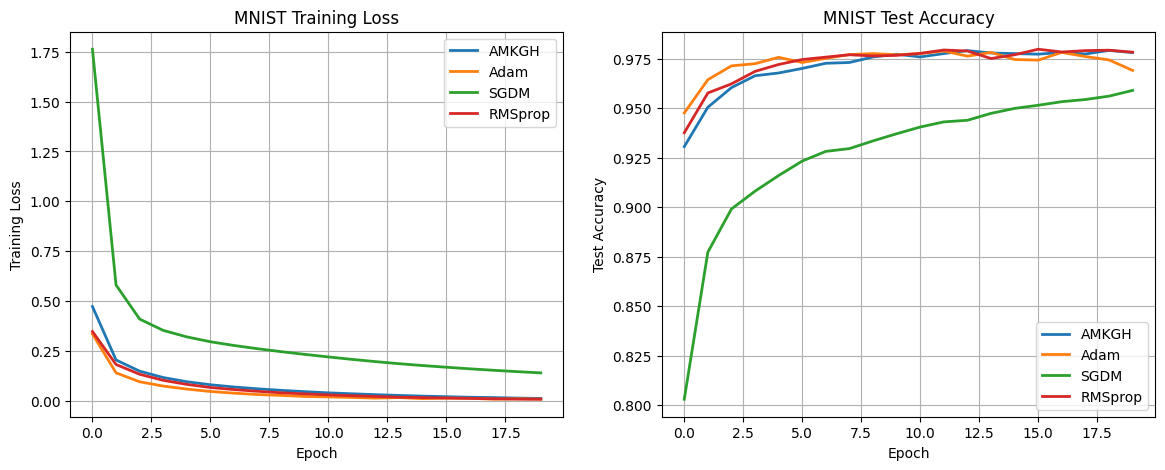


All experiments finished successfully.


In [16]:
# ================================================================
# 7. Main Execution Block
# ================================================================
if __name__ == "__main__":
    print(f"Starting FM216 Project Experiments on {device}")
    
    # A. Well-Conditioned Quadratic (Cond=10)
    run_quadratic(cond=10)

    # B. Ill-Conditioned Quadratic (Cond=100)
    run_quadratic(cond=100)

    # C. Rosenbrock Function (The Hard One)
    run_rosenbrock()

    # D. MNIST Training
    run_mnist(epochs=20)

    print("\nAll experiments finished successfully.")


=== Experiment: Heavy-Tailed Gradient Noise (Prob=0.04) ===


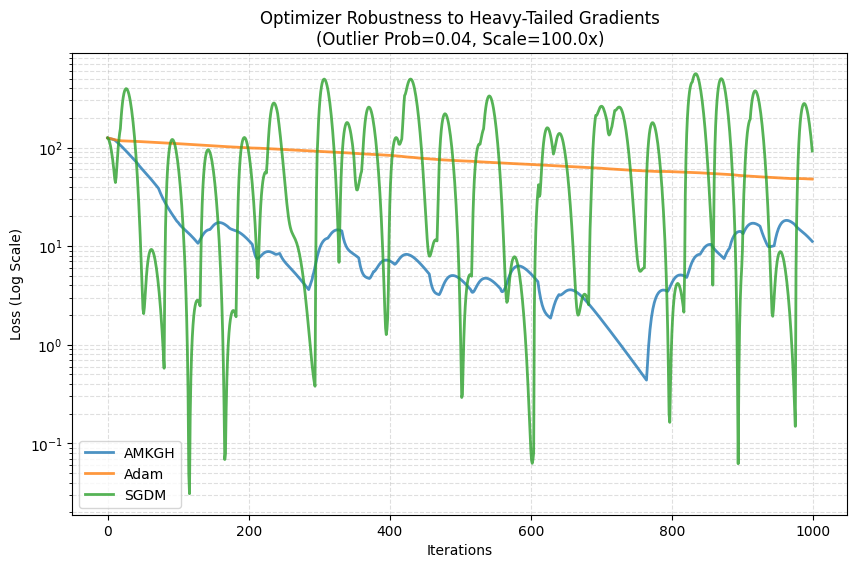

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Ensure AMKGH class is defined before running this (run Cell 2 in your notebook first)

def run_heavy_tail_experiment(dim=10, iterations=1000, outlier_prob=0.05, outlier_scale=50.0):
    print(f"\n=== Experiment: Heavy-Tailed Gradient Noise (Prob={outlier_prob}) ===")
    
    # Setup consistent problem
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(42)
    
    # Target: A simple Quadratic Bowl
    # We use a simple identity matrix Hessian so the problem is easy, 
    # ensuring that any failure is due to NOISE, not curvature.
    
    # Starting point far from origin
    start_point = torch.ones(dim, device=device) * 5.0
    
    optimizers = {
        "AMKGH": lambda p: AMKGH(p, lr=0.01, lambda_k=0.5, kurtosis_max=50), # Higher damping for noise
        "Adam": lambda p: torch.optim.Adam(p, lr=0.01),
        "SGDM": lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9)
    }
    
    history = {name: [] for name in optimizers}
    
    for name, opt_fn in optimizers.items():
        # Reset parameters for fair comparison
        params = start_point.clone().detach().requires_grad_(True)
        opt = opt_fn([params])
        
        loss_curve = []
        
        for t in range(iterations):
            opt.zero_grad()
            
            # 1. Compute True Loss/Gradient
            loss = 0.5 * torch.sum(params**2)
            loss.backward()
            
            # 2. INJECT HEAVY TAIL NOISE (The crucial part)
            # With small probability, add a MASSIVE spike to gradients
            with torch.no_grad():
                if np.random.rand() < outlier_prob:
                    # Create impulsive noise (heavy tail simulation)
                    noise = torch.randn_like(params.grad) * outlier_scale
                    params.grad.add_(noise)
            
            # 3. Step
            opt.step()
            loss_curve.append(loss.item())
            
        history[name] = loss_curve

    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    for name, curve in history.items():
        plt.plot(curve, label=name, linewidth=2, alpha=0.8)
    
    plt.yscale("log")
    plt.xlabel("Iterations")
    plt.ylabel("Loss (Log Scale)")
    plt.title(f"Optimizer Robustness to Heavy-Tailed Gradients\n(Outlier Prob={outlier_prob}, Scale={outlier_scale}x)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.show()
    
    return history

# Run the experiment
# This simulates a scenario where 4% of gradients are massive outliers (High Kurtosis)
_ = run_heavy_tail_experiment(outlier_prob=0.04, outlier_scale=100.0)

Running Experiment 1: Heavy-Tailed Gradient Noise...


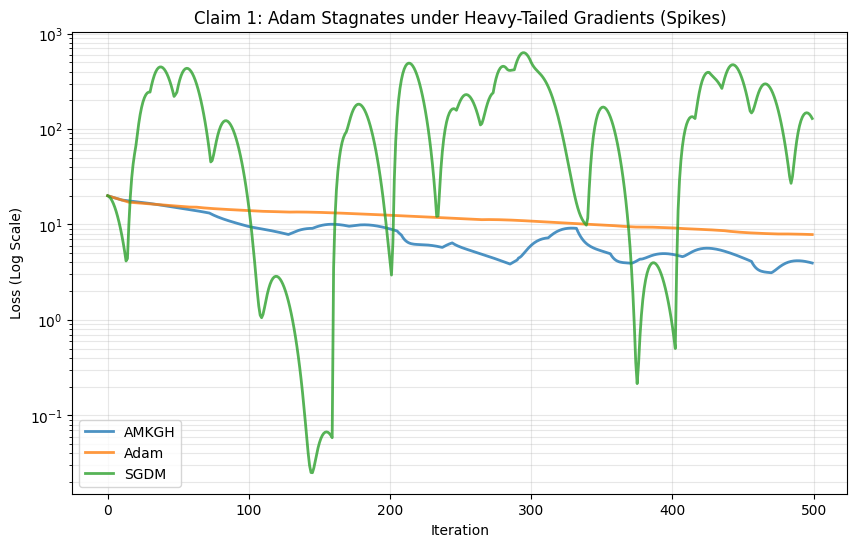

Running Experiment 2: Rosenbrock Trajectory...


/var/folders/81/5vg9fh8978x336lpgxdwmw280000gn/T/ipykernel_21689/938800842.py:140: RuntimeWarning: overflow encountered in scalar power
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/var/folders/81/5vg9fh8978x336lpgxdwmw280000gn/T/ipykernel_21689/938800842.py:141: RuntimeWarning: overflow encountered in scalar power
  dy = 200 * (y - x**2)
/var/folders/81/5vg9fh8978x336lpgxdwmw280000gn/T/ipykernel_21689/938800842.py:140: RuntimeWarning: invalid value encountered in scalar subtract
  dx = -2 * (1 - x) - 400 * x * (y - x**2)
/var/folders/81/5vg9fh8978x336lpgxdwmw280000gn/T/ipykernel_21689/938800842.py:141: RuntimeWarning: invalid value encountered in scalar subtract
  dy = 200 * (y - x**2)


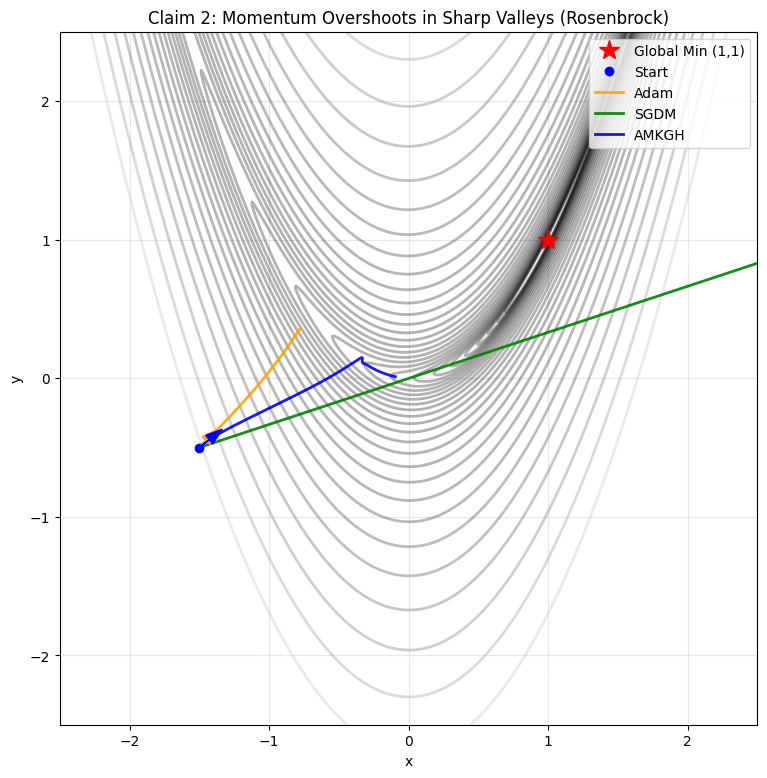

In [11]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set global seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ==============================================================================
# PART 1: HEAVY-TAILED NOISE EXPERIMENT (PyTorch)
# Claim: Adam becomes overly aggressive/stagnates when gradients have high variance.
# ==============================================================================

class AMKGH(torch.optim.Optimizer):
    """
    Adaptive Moment Kurtosis-Gated Hybrid Optimizer.
    Switches between Adam-style and SGD-style updates based on Kurtosis.
    """
    def __init__(self, params, lr=0.002, betas=(0.9, 0.999), beta4=0.999,
                 lambda_k=0.1, kurtosis_max=35.0, eps=1e-8):
        defaults = dict(lr=lr, betas=betas, beta4=beta4, lambda_k=lambda_k,
                        kurtosis_max=kurtosis_max, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            beta4 = group["beta4"]
            lambda_k = group["lambda_k"]
            kurtosis_max = group["kurtosis_max"]
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad.data
                
                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["E4"] = torch.zeros_like(p.data)

                m, v, E4 = state["m"], state["v"], state["E4"]
                state["step"] += 1
                t = state["step"]

                # 1. Update Moments
                m.mul_(beta1).add_(grad, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                E4.mul_(beta4).add_(grad.pow(4), alpha=1 - beta4)

                # 2. Bias Correction
                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)

                # 3. Kurtosis & Gating
                K_t = E4 / (v_hat.pow(2) + eps)
                K_clipped = torch.clamp(K_t, max=kurtosis_max)
                s_t = 1.0 / (1.0 + lambda_k * K_clipped)

                # 4. Hybrid Switching
                smart_dir = m_hat / (torch.sqrt(v_hat) + eps) # Adam-like
                dumb_dir = m                                  # SGD-like
                
                hybrid_dir = (s_t * smart_dir) + ((1.0 - s_t) * dumb_dir)
                p.data.add_(hybrid_dir, alpha=-lr)
        return loss

def run_heavy_tail_experiment():
    print("Running Experiment 1: Heavy-Tailed Gradient Noise...")
    dim = 10
    iterations = 500
    outlier_prob = 0.04   # 4% chance of outlier
    outlier_scale = 100.0 # 100x magnitude spike

    # Start far from origin
    start_point = torch.ones(dim) * 2.0
    
    opts = {
        "AMKGH": lambda p: AMKGH(p, lr=0.01),
        "Adam": lambda p: optim.Adam(p, lr=0.01),
        "SGDM": lambda p: optim.SGD(p, lr=0.01, momentum=0.9)
    }
    
    history = {}
    for name, opt_fn in opts.items():
        # Reset parameters for fair comparison
        params = start_point.clone().requires_grad_(True)
        opt = opt_fn([params])
        losses = []
        
        for _ in range(iterations):
            opt.zero_grad()
            # Simple Quadratic Loss
            loss = 0.5 * torch.sum(params**2)
            loss.backward()
            
            # --- INJECT HEAVY TAIL NOISE ---
            with torch.no_grad():
                if np.random.rand() < outlier_prob:
                    # Create massive spike
                    noise = torch.randn_like(params.grad) * outlier_scale
                    params.grad.add_(noise)
            
            opt.step()
            losses.append(loss.item())
        history[name] = losses

    # Plotting
    plt.figure(figsize=(10, 6))
    for name, loss in history.items():
        plt.plot(loss, label=name, alpha=0.8, linewidth=2)
    plt.yscale("log")
    plt.title("Claim 1: Adam Stagnates under Heavy-Tailed Gradients (Spikes)")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (Log Scale)")
    plt.legend()
    plt.grid(True, alpha=0.3, which='both')
    plt.show()

# ==============================================================================
# PART 2: ROSENBROCK TRAJECTORY EXPERIMENT (Numpy)
# Claim: Momentum overshoots in high-curvature regions.
# ==============================================================================

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

# Numpy implementations of optimizers for trajectory plotting
def step_adam_np(params, grads, state, lr=0.005, beta1=0.9, beta2=0.999, eps=1e-8):
    if 'm' not in state:
        state['m'] = np.zeros_like(params); state['v'] = np.zeros_like(params); state['t'] = 0
    state['t'] += 1
    t = state['t']
    state['m'] = beta1 * state['m'] + (1 - beta1) * grads
    state['v'] = beta2 * state['v'] + (1 - beta2) * grads**2
    m_hat = state['m'] / (1 - beta1**t)
    v_hat = state['v'] / (1 - beta2**t)
    update = lr * m_hat / (np.sqrt(v_hat) + eps)
    return params - update

def step_sgdm_np(params, grads, state, lr=0.005, momentum=0.9):
    if 'v' not in state: state['v'] = np.zeros_like(params)
    state['v'] = momentum * state['v'] + grads
    return params - lr * state['v']

def step_amkgh_np(params, grads, state, lr=0.005, betas=(0.9, 0.999), lambda_k=0.1, k_max=35.0, eps=1e-8):
    if 'm' not in state:
        state['m'] = np.zeros_like(params); state['v'] = np.zeros_like(params)
        state['e4'] = np.zeros_like(params); state['t'] = 0
    state['t'] += 1
    t = state['t']
    b1, b2 = betas
    state['m'] = b1 * state['m'] + (1 - b1) * grads
    state['v'] = b2 * state['v'] + (1 - b2) * grads**2
    state['e4'] = b2 * state['e4'] + (1 - b2) * grads**4
    
    m_hat = state['m'] / (1 - b1**t)
    v_hat = state['v'] / (1 - b2**t)
    
    k_t = state['e4'] / (v_hat**2 + eps)
    k_clip = np.minimum(k_t, k_max)
    s_t = 1.0 / (1.0 + lambda_k * k_clip)
    
    smart = m_hat / (np.sqrt(v_hat) + eps)
    dumb = state['m']
    hybrid = s_t * smart + (1.0 - s_t) * dumb
    return params - lr * hybrid

def run_rosenbrock_trajectory():
    print("Running Experiment 2: Rosenbrock Trajectory...")
    start_pos = np.array([-1.5, -0.5])
    iterations = 300 
    lr = 0.005
    
    trajectories = {}
    
    # Simulators
    sims = [
        ('Adam', step_adam_np),
        ('SGDM', step_sgdm_np),
        ('AMKGH', step_amkgh_np)
    ]
    
    for name, step_fn in sims:
        p = start_pos.copy()
        state = {}
        path = [p.copy()]
        for _ in range(iterations):
            g = rosenbrock_grad(p[0], p[1])
            p = step_fn(p, g, state, lr=lr)
            path.append(p.copy())
        trajectories[name] = np.array(path)
    
    # Plotting
    x = np.linspace(-2.5, 2.5, 400)
    y = np.linspace(-2.5, 2.5, 400)
    X, Y = np.meshgrid(x, y)
    Z = rosenbrock(X, Y)
    
    plt.figure(figsize=(9, 9))
    plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 30), cmap='gray', alpha=0.3)
    
    plt.plot(1, 1, 'r*', markersize=15, label='Global Min (1,1)', zorder=10)
    plt.plot(start_pos[0], start_pos[1], 'bo', label='Start', zorder=5)
    
    colors = {'AMKGH': 'blue', 'SGDM': 'green', 'Adam': 'orange'}
    
    for name, path in trajectories.items():
        plt.plot(path[:, 0], path[:, 1], label=name, color=colors[name], linewidth=2, alpha=0.9)
        # Add arrow for direction
        if len(path) > 10:
            plt.arrow(path[0,0], path[0,1], path[10,0]-path[0,0], path[10,1]-path[0,1], 
                      head_width=0.08, color=colors[name], zorder=6)

    plt.xlim(-2.5, 2.5)
    plt.ylim(-2.5, 2.5)
    plt.title("Claim 2: Momentum Overshoots in Sharp Valleys (Rosenbrock)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_heavy_tail_experiment()
    run_rosenbrock_trajectory()


=== Optimizer Convergence Race (Goal: Loss < 0.0001) ===

--- Final Results ---
AMKGH     : Converged in 2464 iterations
Adam      : FAILED to converge (Final Loss: 1.7107)
SGDM      : Converged in 837 iterations
RMSprop   : FAILED to converge (Final Loss: 0.0004)


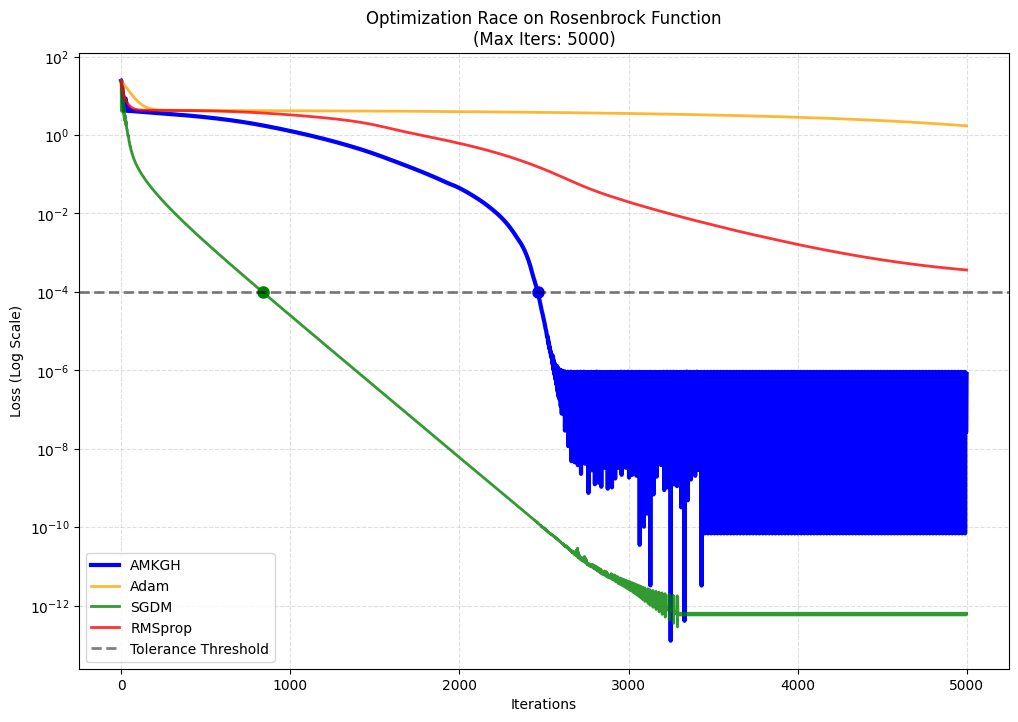

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def run_convergence_race(max_iter=5000, tol=1e-4):
    print(f"\n=== Optimizer Convergence Race (Goal: Loss < {tol}) ===")
    
    # 1. Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    def f_rosen(theta):
        x, y = theta[0], theta[1]
        return (1 - x)**2 + 100 * (y - x**2)**2

    # Start at standard difficult point
    start_tensor = torch.tensor([-1.2, 1.0], device=device)
    
    # Create independent copies of parameters
    param_dict = {
        "AMKGH": start_tensor.clone().detach().requires_grad_(True),
        "Adam": start_tensor.clone().detach().requires_grad_(True),
        "SGDM": start_tensor.clone().detach().requires_grad_(True),
        "RMSprop": start_tensor.clone().detach().requires_grad_(True),
    }

    # Initialize Optimizers
    opts = {
        "AMKGH": AMKGH([param_dict["AMKGH"]], lr=1e-3, lambda_k=0.2, hybrid_weight=0.1),
        "Adam": torch.optim.Adam([param_dict["Adam"]], lr=1e-3),
        "SGDM": torch.optim.SGD([param_dict["SGDM"]], lr=1e-3, momentum=0.9),
        "RMSprop": torch.optim.RMSprop([param_dict["RMSprop"]], lr=1e-3)
    }

    # Track history and success
    loss_history = {name: [] for name in opts}
    success_iter = {name: None for name in opts}
    
    # 2. The Race Loop
    for step in range(1, max_iter + 1):
        all_converged = True
        
        for name, opt in opts.items():
            # Skip updates if already converged (optional, usually we let them refine)
            # if success_iter[name] is not None: 
            #    loss_history[name].append(loss_history[name][-1])
            #    continue
                
            p = param_dict[name]
            opt.zero_grad()
            loss = f_rosen(p)
            loss.backward()
            opt.step()
            
            val = loss.item()
            loss_history[name].append(val)
            
            # Check for victory
            if val < tol and success_iter[name] is None:
                success_iter[name] = step
            
            # Check if anyone is still running
            if success_iter[name] is None:
                all_converged = False
        
        # Stop early if everyone is done
        if all_converged:
            print(f"All optimizers converged by iteration {step}. Stopping early.")
            break

    # 3. Print Results
    print("\n--- Final Results ---")
    for name, iter_count in success_iter.items():
        if iter_count:
            print(f"{name:<10}: Converged in {iter_count} iterations")
        else:
            final_loss = loss_history[name][-1]
            print(f"{name:<10}: FAILED to converge (Final Loss: {final_loss:.4f})")

    # 4. Plotting
    plt.figure(figsize=(12, 8))
    
    styles = {
        "AMKGH":   {"color": "blue", "linewidth": 3, "alpha": 1.0},
        "Adam":    {"color": "orange", "linewidth": 2, "alpha": 0.8},
        "SGDM":    {"color": "green", "linewidth": 2, "alpha": 0.8},
        "RMSprop": {"color": "red", "linewidth": 2, "alpha": 0.8}
    }

    for name, losses in loss_history.items():
        style = styles.get(name, {})
        plt.plot(losses, label=name, **style)
        
        # Mark the convergence point
        if success_iter[name]:
            idx = success_iter[name] - 1
            plt.plot(idx, losses[idx], 'o', color=style['color'], markersize=8)

    plt.axhline(y=tol, color='k', linestyle='--', alpha=0.5, label='Tolerance Threshold')
    plt.yscale('log')
    plt.title(f'Optimization Race on Rosenbrock Function\n(Max Iters: {max_iter})')
    plt.xlabel('Iterations')
    plt.ylabel('Loss (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.show()

# Run it
run_convergence_race()